A. Noah Benevides, Nab18035

B. Objectives:
The objectives of this assingment were to complete two major types of machine learning pipelines that would tackle certain questions and requirements based on a provided data set.  Using the OCT-MNIST (Optical Coherence Tomography) data set, two pipelines were to be designed that could accurately predict the label of an inputted image.  One of these pipelines was to use a combination of classifiers, while the other was to use an artifical neural network.  Both final pipelines were to be chosen from a series of options, decided upon their metrics related to the validation data set.  After this, they were to be compared based upon the test data set for a final evaluation.  Metrics that were to be measured include accuracy, precision, recall, confusion matrix, AUC, and the ROC curve for each.  Of the alternate designs, one of each pipeline type needed to use dimensionality reduction of some sort.  Also, the chosen designs needed to go through some form of parametric optimization before the final testing and analysis.

C. Methods:
I can best speak to the methods used to design pipeline 1, but I will also attempt to reason why specific choices were made in the decisions of pipeline 2's various designs.  

Due to the data already being pre-processed and separated into training, testing, and validation data, not much preparation was neccessary.  The code made sure that the file was imported, and that the sub sections were each represented in x and y values.  The x values were scaked with a min max scaler so that they ranged from 0 to 1 instead of the initial 0 to 255 of an image, and the y values were shifted to an index of 0 to 3 instead of 1 to 4 for better processing.  

A test KNN classifier was run to get a general idea of what an accuracy reading could be without layering multiple classifiers together.  Next, the first classifier was designed.  This classifier was an ensemble of a KNN and RF classifier that used hard voting.  Hard voting was used across all classifiers in pipeline 1 for consistency and faster processing times.  An initial idea was to run all of the classifiers on 40,000 data points, but this later proved to not work as a future design would have taken far over the maximum of 8 hours of running time on colab to complete.  The combination of a KNN and RF seemed like a simple layering to start with, that also had enough complexity to provide accuracy in results.  Random forest classifiers are best with non-linear relationships, while KNN classifiers are best at finding localized relationships.  This mixture should work well together and add multiple approaches to the data set, while decreasing overall variance, and improving results overall.  A stacked version creates a new model based on the results of its components, while the ensemble treats them as indipendent agents and weighs the voting based on their results.  The stack is thus far more complex and takes much longer to run, but could increase accuracy due to the combination of methods.  

The second design contunues using an ensemble with hard voting, and relies on a combination of SVC, Gaussian, and RF classifiers in order to process the input images.  SVC is particullarly skilled at high dimensional data such as the input images, and is able to make use of hyperplanes to differentiate between features.  Gaussian classifiers are best for large data sets, and thus do not impact the run time as much as other classifiers.  Gaussian also looks for independent relationships, and thus provides a different perspective than the other classifiers being used.  Together, over fitting should not be an issue, and the stack of classifiers should effectively find different patterns within the data.  This ensemble should be a highly effective, yet slower way to accurately predict outcomes.  Due to confidence in this method, it was tested both on validation data and on test data.  A tqdm progress bar was also implemented so that running time could be predicted, and parameters could be adjusted accordingly.

The third design for pipeline 1 builds off of the first design, but adds an additional layer to the ensemble and makes use of dimensionality reduction.  Principal component analysis was run on the image data, and a value of 0.9 was used.  This ensures that 90% of the data is retained, but extra features that may not assist with accuracy were removed.  This can also decrease any chance of over-training or a classifier searching for a pattern that is unhelpful.  Running the PCA increased running time drastically.  The third design could be run on all of the data points due to this.  The ensemble made use of the original design, but also added an AdaBoost classifier.  This classifer uses weak learners to focus on difficult features to classify.  This should boost results on wherever the first ensemble is lacking, and make up for the missing data from the PCA.  

A grid search was performed on the first ensemble classifier as it yielded the highest accuracy overall.  A very low cv value of 2 was used to optimize time.  This may decrease the results of the grid search, but initial searches with a cv of 5 and less parameters in the parameter grid did not yield any better results.  This search looked for n_neighbors and n_estimators through the voting classifier used in the first ensemble.  Optimizing them together may take longer, but it represents the exact same system that will be used.  The n_neighbors value was optimized due to its massive importance to KNN classifiers.  It likely has the largest impact out of any parameter for KNNs.  Also, n_estimators was optimized for the same reason, as it largely impacts the accuracy of the RF classifier, and is likely the most import parameter to change.  These values were then used on the test data, and measurements of accuracy, precision, recall, the confusion matrix, ROC curve, and AUC values were all taken for analysis.  

An alternate form of optimization was also tried.  This code separated the KNN and RF classifiers and optimized them separately, but with more parameters.  The KNN classifier was additionally optimzied for leaf_size, and the RF classifier was additionally optimized for max_depth.  The leaf_size is important as it sets the minimum amount of data points that reach a final node, while max_depth determines how deep a decision tree will branch out.  These parameters together can alter how many levels there are and how many data points are in those levels.  This combination seems to be a good way to improve accuracy and to approach the same problem from opposite sides.  These alternate optimizations were then tested on the test data to compare to the regular optimized results.

For pipeline 2, seven different designs exist in total.  The first CNN network makes use of max pooling layers, flattening, dense layers, and dropout.  This particular design uses a 3x3 convultional layer that uses increasing filter sizes from 32 up to 128 to increase learning as the program progresses.  Max pooling layers are used to reduce the dimensionality of the data, while relu is used to help with non-linearity.  The dropout helps prevent overfitting and reduces the total number of neurons being used.  The flattening also helps the learning process from the dense layers.  The second version of this network also implements batch normalization which can increase processing speeds and the efficiency of the layers.  For these networks and all going forward, loss, accuracy, precision, recall, F1 score, and a confusion matrix were measured after 10 epochs, and the use of macro averaging.

For CNN2 version 1, the layout is relatively similar to the first networks, but padding and a layer with 256 filters is employed.  This even larger layer makes it more complex, and the padding helps maintain the dimensions between the convolutions.  This is a more powerful design but in turn would take longer to run.  This should be more accurate, but could be prone to overfitting the data.  Due to the complexity of the data though, this should not be an issue. Version 2 of CNN2 adds in the use of another kernel of 5 x 5 instead of just the 3 x 3 kernel used in all previous iterations.  This increase in size may help with finding broader patterns early on in the learning process before using a smaller searching tool with the 3 x 3 kernels.  Due to this and the increased number of total layers, the first version should run faster than this one, but this could be even more accurate due to its complexity.

MLP (multi-layer perceptron) version 1 makes use of a standard scaler and reshapes the data before it is further processed with a PCA that maintains 50 components.  This process should improve performance speed and efficency before running the data through the MLP.  MLPs are good for small datasets, so the PCA transforms the existing data into something that can be used properly by this method.  The MLP makes use of far less layers, but in turn saves on time and computational power.  Version 2 of the MLP introduces far more layers, and uses an inverted strategy from before.  Instead of building up the number of neurons, it starts large and decreases at each filter.  Different dropouts are also employed in order to match the sizes of the layers, and batch normalization helps improve training speed and efficiency.

CNN2 version 1 was chosen for optimization.  This network used a paramter grid that focused on different neuron values, activators, and optimizers.  Relu was used before but tanh does not have the risk of "dead neurons", although it can be much slower.  For the optimizers, adam was commonly used, but rmsprop is better for sparse gradients if they exist in the data.  This section would logically next use the grid search's results to then be used on the test data, but this was not completed when I was given the code in Apendix 2.

D. Results:
When the different designs of pipeline 1 were created, they were tested for accuracy on the validation data.  The first design of pipleine one was tested in two different manners.  One of these was an ensemble of the KNN classifier and the RF classifier, while the other was a stack of these two.  The ensemble produced an accuracy reading of 0.7142, while the stack only had an accuracy of 0.4763.  For these tests, 40,000 data points were used for the ensemble, and only 250 were used for the stack out of a pool of 2000.  This was due to the large time difference in how long it would take to run the cells.  Noting the faster time and accuracy of the ensemble, the alternate deisgns also made use of an ensemble format.  Many tests were run on the second design of the first pipeline.  This ensemble of an SVC, GNB, and RF classifier ended up running for 4 and a half hours on its final test, and produced an accuracy of 0.5676.  Even with this incredible amount of time, it still failed to beat the accuracy of the first design.  This design was further tested on the test data, and revealed an accuracy rating of just 0.346 as can be seen below.

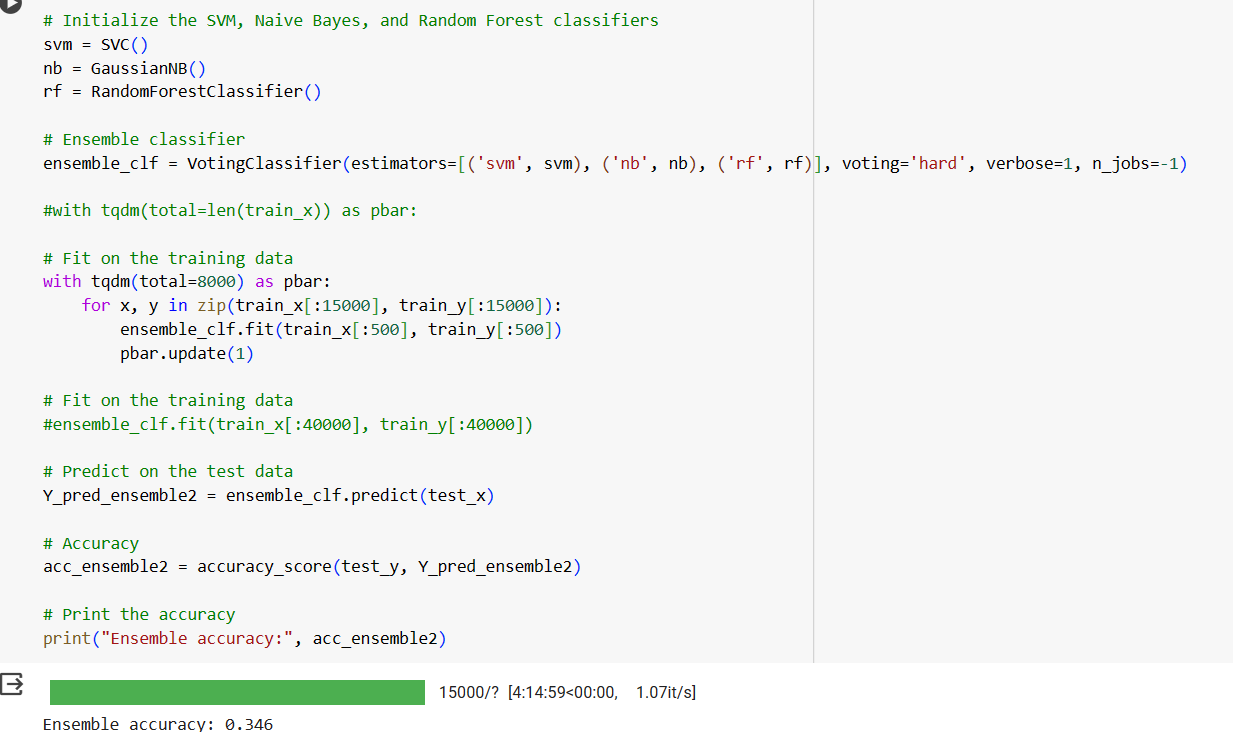

The third design for pipeline one made use of a PCA of 0.9 which greatly increased its speed.  Its overall accuracy was very close to the first design's at 0.6943.  This pipeline produced these results when being tested on the entire dataset, and while it showed great speed, it could not beat the first design when it only used less than half of the total datapoints.  A grid search for the first design revealed optimized parameters of n_neighbors = 5, and n_estimators = 2000.  These were then used on validation data and an accuracy of 0.7184 was found.  This was only a 0.59% increase overall.

A final set of tests were completed on the first classifier of the first pipeline to see if changing the optimization style would be beneficial.  Instead of optimizing the RF and KNN together, they were each optimized separately, and for more total parameters.  This yielded the results that for the KNN classifier the optimal values would be n_neighbors = 9, and leaf_size = 10.  For the RF classifier (which took much longer to optimize), the values were n_estimators = 1000, and max_depth = 11.  Combining these only resulted in an accuracy and recall score of 0.484, and a precision of 0.5552 on the test data.

Pipeline 2 had 7 different desings.  These are named- CNN1,CNN2 (version 1 and 2 for both),and MLP (version 1 and 2).  CNN1 resulted in an accuracy of 0.8885, precision of 0.83, and recall of 0.75.  These values are far higher than the values found by any of pipeline 1's designs.  CNN1 version 2 resulted in an accuracy of 0.8878, precision of 0.86, and recall of 0.74.  CNN2 resulted in an even higher accuracy of 0.9225, a precision of 0.88, and a recall of 0.83.  CNN2 version 2 was optimized to have an accuracy of 0.9223, a precision of 0.87, and a recall of 0.86.  The MLPs did not perform as well as the CNNs, but were still more accurate than the pipeline 1 designs.  MLP version 1 had an accruacy of 0.7812, a precision of 0.59, and a recall of 0.55.  MLP version 2 increased these values to an accuracy of 0.7844, precision of 0.6, and the recall stood the same at a value of 0.55.

When pipeline 1 was tested on the test data, the accuracy and recall were 0.518.  The precision was slightly higher at 0.525, and the confusion matrix can be seen lower in Appendix 1.  According to the AUC scores, a label of normal or choroidal neovascularization were only accurate 20% and 35% of the time respectfully.  In comparison, the values for diabetic macular edema and drusen were much higher at 66% and 79% respectfully.  The alternate optimization route produced a higher precision for on the test data, but its accuracy and recall were not as high.

I was not yet given all of the information about the best network being run on test data.  I did see that the best network resulted in an accuracy of 0.9248 which is far higher than anything achieved in pipeline 1.  

E. Conclusion:
It is rather clear from the results that the neural networks far outpreformed the classifiers.  I would be curious to see the AUC results of the neural networks to see how each individual label compared.  It could be possible that the classifiers are inherently better at certain categories, while the nerual networks are better at others, or they have an even distrubiton of accuracy across them all.  It seems that the neural networks were far more capable at producing true positives (recall values), had a higher level of repeatability (precision), and were overall more accurate.  If I had more time I would dedicate more resources to optimizing the other pipeline 1 networks and seeing how they fared with better values being used.  I would also like to experiment more with the stacking and changing the voting from hard to soft, and see its effects.

F. Self Reflection:
The course greatly met the course objectives.  Pipelines for machine learning were designed, tested, and revised.  These pipeleines were used on various types of data coming from different types of files.  Instructions on how to prepare data for use in a pipeline was given on multiple occassions.  Things such as dimensionality reduction and how to work with large or small data sets were discussed extensively.  Metrics were used to analyze the efficiency of different approaches.  These included more simplistic measurements such as accuracy, but also more advanced ones such as an ROC curve.  The Scikit-Learn software was used weekly throughout classes and assingments.  The later parts of the course focused on convulitional filters and pooling techniques in order to optimize a network.  All of this effectively explained the differences between deep learning and shallow learning, as well as the differences between classifiers and regressors, and the differences between various types of neural networks.

In this final project, the work was split between the two major pipelines.  I focused on the classifiers pipeline, while my partner focused on the neural networks.  I have split the appendix into two parts (Appendix 1 and Appendix 2) to better represent our work.  We did discuss and help one another with the coding of each pipeline, but the majority of the work was split in this fashion.


Appendix 1:

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [3]:
import tarfile
import urllib

In [4]:
#import all potential tools and libraries
!pip install scikit-learn
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedShuffleSplit as strata
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_predict
from sklearn import tree
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, auc
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import KFold
from sklearn import datasets, linear_model
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, IncrementalPCA, KernelPCA
from sklearn.metrics import mean_squared_error, confusion_matrix
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from google.colab import files
uploaded = files.upload()

Saving octmnist.npz to octmnist.npz


In [6]:
import numpy as np

data = np.load('octmnist.npz')

In [7]:
#for name in data:
  #  print(name)
  #  print(data[name])

In [8]:
test_x = data['test_images']
test_y = data['test_labels']

train_x = data['train_images']
train_y = data['train_labels']

val_x = data['val_images']
val_y = data['val_labels']

In [9]:
np.info(data)

NpzFile(fid)

A dictionary-like object with lazy-loading of files in the zipped
archive provided on construction.

`NpzFile` is used to load files in the NumPy ``.npz`` data archive
format. It assumes that files in the archive have a ``.npy`` extension,
other files are ignored.

The arrays and file strings are lazily loaded on either
getitem access using ``obj['key']`` or attribute lookup using
``obj.f.key``. A list of all files (without ``.npy`` extensions) can
be obtained with ``obj.files`` and the ZipFile object itself using
``obj.zip``.

Attributes
----------
files : list of str
    List of all files in the archive with a ``.npy`` extension.
zip : ZipFile instance
    The ZipFile object initialized with the zipped archive.
f : BagObj instance
    An object on which attribute can be performed as an alternative
    to getitem access on the `NpzFile` instance itself.
allow_pickle : bool, optional
    Allow loading pickled data. Default: False

    .. versionchanged:: 1.16.3
        Ma

In [10]:
# Import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

In [11]:
#scaler
# Reshape train_x to be 2D
train_x = train_x.reshape(train_x.shape[0], -1)

# Fit the scaler to the reshaped data
scaler.fit(train_x)

MinMaxScaler()

In [12]:
#reshape others
val_x = val_x.reshape(val_x.shape[0], -1)
test_x = test_x.reshape(test_x.shape[0], -1)

In [13]:
train_x = scaler.transform(train_x)
val_x = scaler.transform(val_x)
test_x = scaler.transform(test_x)

In [14]:
#Test run

In [15]:
KNN = KNeighborsClassifier()
KNN.fit(train_x, train_y)
Y_pred_R1 = KNN.predict(val_x)
acc_R1 = accuracy_score(val_y, Y_pred_R1)
print("Routine 1 accuracy = ", acc_R1)

Routine 1 accuracy =  0.7127031019202363


In [16]:
#Would reindex the data to 0-3 but it is already stored as such

In [17]:
val_y_df = pd.DataFrame(val_y)
print(val_y_df.head(10))

   0
0  3
1  0
2  3
3  3
4  0
5  1
6  3
7  0
8  0
9  3


In [18]:
# Would convert X vals by dividing by 255 for the pixel count, but the values are already on this scale

In [19]:
train_x_df = pd.DataFrame(train_x)
print(train_x_df.head(10))

        0         1         2         3         4         5         6    \
0  0.090196  0.094118  0.098039  0.094118  0.086275  0.082353  0.086275   
1  0.133333  0.129412  0.121569  0.113725  0.113725  0.113725  0.117647   
2  0.674510  0.658824  0.631373  0.607843  0.584314  0.556863  0.525490   
3  0.729412  0.729412  0.725490  0.721569  0.713725  0.698039  0.686275   
4  0.098039  0.086275  0.078431  0.070588  0.066667  0.066667  0.074510   
5  1.000000  1.000000  1.000000  1.000000  1.000000  0.992157  0.988235   
6  0.160784  0.105882  0.101961  0.113725  0.098039  0.105882  0.121569   
7  0.066667  0.066667  0.066667  0.066667  0.066667  0.066667  0.066667   
8  0.372549  0.388235  0.415686  0.450980  0.490196  0.529412  0.556863   
9  1.000000  1.000000  1.000000  1.000000  0.996078  0.996078  0.992157   

        7         8         9    ...       774       775       776       777  \
0  0.090196  0.105882  0.086275  ...  0.039216  0.035294  0.031373  0.031373   
1  0.117647  0

In [20]:
#Ensemble random forest + knn

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

# Initialize the KNN and Random Forest classifiers
knn = KNeighborsClassifier()
rf = RandomForestClassifier()

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('knn', knn), ('rf', rf)], voting='hard', verbose = 0)

# Fit on the training data
ensemble_clf.fit(train_x[:40000], train_y[:40000])

# Predict
Y_pred_ensemble = ensemble_clf.predict(val_x)

# Accuracy
acc_ensemble = accuracy_score(val_y, Y_pred_ensemble)

# Print the accuracy
print("Ensemble accuracy:", acc_ensemble)

Ensemble accuracy: 0.7141802067946824


In [22]:
# stacked version of knn and random forest

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

In [24]:
train_x.shape

(97477, 784)

In [25]:
train_y.shape

(97477, 1)

In [26]:
from tqdm.auto import tqdm

In [116]:
#stack version of above ^
from tqdm.auto import tqdm

knn = KNeighborsClassifier()
rf = RandomForestClassifier()
logistic_regression = LogisticRegression()

# Create the stacking classifier
stacking_clf = StackingClassifier(estimators=[('knn', knn), ('rf', rf)], final_estimator=logistic_regression, cv=2)

# Fit on the training data
with tqdm(total = 500) as pbar:
    for x, y in zip(train_x[:2000], train_y[:2000]):
        stacking_clf.fit(train_x[:250], train_y[:250])
        pbar.update(1)

# Predict
Y_pred_stacking = stacking_clf.predict(val_x)

# Accuracy
acc_stacking = accuracy_score(val_y, Y_pred_stacking)

  0%|          | 0/500 [00:00<?, ?it/s]

In [117]:
print(("Stacking accuracy:", acc_stacking))

('Stacking accuracy:', 0.47636632200886264)


In [29]:
# Ensemble SVC w/ random forest

In [30]:
#for current matrix

In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

# Initialize the SVM, Naive Bayes, and Random Forest classifiers
svm = SVC()
nb = GaussianNB()
rf = RandomForestClassifier()

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('svm', svm), ('nb', nb), ('rf', rf)], voting='hard', verbose=1, n_jobs=-1)

#with tqdm(total=len(train_x)) as pbar:

# Fit on the training data
with tqdm(total=8000) as pbar:
    for x, y in zip(train_x[:15000], train_y[:15000]):
        ensemble_clf.fit(train_x[:500], train_y[:500])
        pbar.update(1)

# Fit on the training data
#ensemble_clf.fit(train_x[:40000], train_y[:40000])

# Predict on the test data
Y_pred_ensemble2 = ensemble_clf.predict(val_x)

# Accuracy
acc_ensemble2 = accuracy_score(val_y, Y_pred_ensemble2)

# Print the accuracy
print("Ensemble accuracy:", acc_ensemble2)

  0%|          | 0/8000 [00:00<?, ?it/s]

Ensemble accuracy: 0.5675775480059084


In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

# Initialize the SVM, Naive Bayes, and Random Forest classifiers
svm = SVC()
nb = GaussianNB()
rf = RandomForestClassifier()

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('svm', svm), ('nb', nb), ('rf', rf)], voting='hard', verbose=1, n_jobs=-1)

#with tqdm(total=len(train_x)) as pbar:

# Fit on the training data
with tqdm(total=40000) as pbar:
    for x, y in zip(train_x[:40000], train_y[:40000]):
        ensemble_clf.fit(train_x[:200], train_y[:200])
        pbar.update(1)

# Fit on the training data
#ensemble_clf.fit(train_x[:40000], train_y[:40000])

# Predict on the test data
Y_pred_ensemble2 = ensemble_clf.predict(test_x)

# Accuracy
acc_ensemble2 = accuracy_score(test_y, Y_pred_ensemble2)

# Print the accuracy
print("Ensemble accuracy:", acc_ensemble2)

  0%|          | 0/40000 [00:00<?, ?it/s]

In [31]:
# Option 3: Ensemble knn + adaboost + random forest

In [32]:
from sklearn.decomposition import PCA

In [33]:
pca = PCA(n_components=0.9)


pca.fit(train_x)

train_x_pca = pca.transform(train_x)
val_x_pca = pca.transform(val_x)
test_x_pca = pca.transform(test_x)

In [34]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

# Initialize the KNN, Random Forest and AdaBoost classifiers
knn = KNeighborsClassifier()
rf = RandomForestClassifier()
ada = AdaBoostClassifier()

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('knn', knn), ('rf', rf), ('ada', ada)], voting='hard')

# Fit the ensemble classifier on the training data
ensemble_clf.fit(train_x_pca, train_y)

# Predict the labels for the test data
Y_pred_ensemble3 = ensemble_clf.predict(val_x_pca)

# Evaluate the accuracy of the ensemble classifier
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(val_y, Y_pred_ensemble3)
print('Ensemble 3 accuracy:', accuracy)

Ensemble 3 accuracy: 0.6943316100443131


In [35]:
#optimize the current best solution

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {
  'knn__n_neighbors': (3, 4, 5, 6),  # Range of neighbors for KNN
  'rf__n_estimators': np.arange(2000, 20000, 2000 ),  # Range of estimators for Random Forest
}


In [38]:
%%time

# Define the ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('knn', KNeighborsClassifier()), ('rf', RandomForestClassifier())], verbose=0)

# Create the GridSearchCV object
grid_search = GridSearchCV(ensemble_clf, param_grid, scoring='accuracy', cv=2)  # Adjust cv for validation

# Fit the grid search to the training data
grid_search.fit(train_x[:1000], train_y[:1000])




CPU times: user 1h 47min 34s, sys: 16.1 s, total: 1h 47min 50s
Wall time: 1h 49min 1s


GridSearchCV(cv=2,
             estimator=VotingClassifier(estimators=[('knn',
                                                     KNeighborsClassifier()),
                                                    ('rf',
                                                     RandomForestClassifier())],
                                        verbose=0),
             param_grid={'knn__n_neighbors': (3, 4, 5, 6),
                         'rf__n_estimators': array([ 2000,  4000,  6000,  8000, 10000, 12000, 14000, 16000, 18000])},
             scoring='accuracy')

In [39]:
# Get the best parameters from the grid search
best_params = grid_search.best_params_

print(best_params)

{'knn__n_neighbors': 5, 'rf__n_estimators': 2000}


In [40]:
# Initialize the KNN and Random Forest classifiers
knn = KNeighborsClassifier(n_neighbors= 5)
rf = RandomForestClassifier(n_estimators = 2000)

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('knn', knn), ('rf', rf)], voting='hard', verbose = 0)

# Fit on the training data
#with tqdm(total=40000) as pbar:
#    for x, y in zip(train_x[:40000], train_y[:40000]):
#        ensemble_clf.fit(train_x, train_y)
#        pbar.update(1)


# Fit on the training data
ensemble_clf.fit(train_x[:40000], train_y[:40000])

# Predict
Y_pred_ensemble = ensemble_clf.predict(test_x)

# Accuracy
acc_ensemble = accuracy_score(test_y, Y_pred_ensemble)

# Precision (average across all classes)
precision = precision_score(test_y, Y_pred_ensemble, average='weighted')

# Recall (average across all classes)
recall = recall_score(test_y, Y_pred_ensemble, average='weighted')

# Confusion Matrix
confusion_matrix = confusion_matrix(test_y, Y_pred_ensemble)

# Print the accuracy
print("Ensemble accuracy:", acc_ensemble)

Ensemble accuracy: 0.518


In [41]:
#precision
print("Precision:", precision)

Precision: 0.525030949818799


In [42]:
print("Confusion Matrix:", confusion_matrix)

Confusion Matrix: [[220   5   4  21]
 [132  72   5  41]
 [ 64   3   5 178]
 [ 20   2   7 221]]


In [43]:

print("Recall:", recall)

Recall: 0.518


In [44]:
# Print the accuracy
print("Ensemble accuracy:", acc_ensemble)

Ensemble accuracy: 0.518


In [ ]:
# Initialize the KNN and Random Forest classifiers
knn = KNeighborsClassifier(n_neighbors= 5)
rf = RandomForestClassifier(n_estimators = 2000)

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('knn', knn), ('rf', rf)], voting='hard', verbose = 0)

# Fit on the training data
ensemble_clf.fit(train_x[:40000], train_y[:40000])

# Predict
Y_pred_ensemble = ensemble_clf.predict(val_x)

# Accuracy
acc_ensemble = accuracy_score(val_y, Y_pred_ensemble)

# Precision (average across all classes)
precision = precision_score(val_y, Y_pred_ensemble, average='weighted')

# Recall (average across all classes)
recall = recall_score(val_y, Y_pred_ensemble, average='weighted')


# Print the accuracy
print("Ensemble accuracy:", acc_ensemble)

Ensemble accuracy: 0.718426883308715


In [ ]:

print("Recall:", recall)

Recall: 0.718426883308715


In [ ]:


print("Confusion Matrix:", confusion_matrix)

Confusion Matrix: [[223   4   3  20]
 [134  68   5  43]
 [ 68   3   4 175]
 [ 20   2   7 221]]


In [ ]:
print("Ensemble accuracy:", acc_ensemble)#error analysis on test data

Ensemble accuracy: 0.718426883308715


In [ ]:
#accuracy
print("Accuracy:", acc_ensemble)

Accuracy: 0.718426883308715


In [ ]:
#precision
print("Precision:", precision)

Precision: 0.7039646630177142


In [50]:
!pip install seaborn

In [51]:
import seaborn as sns

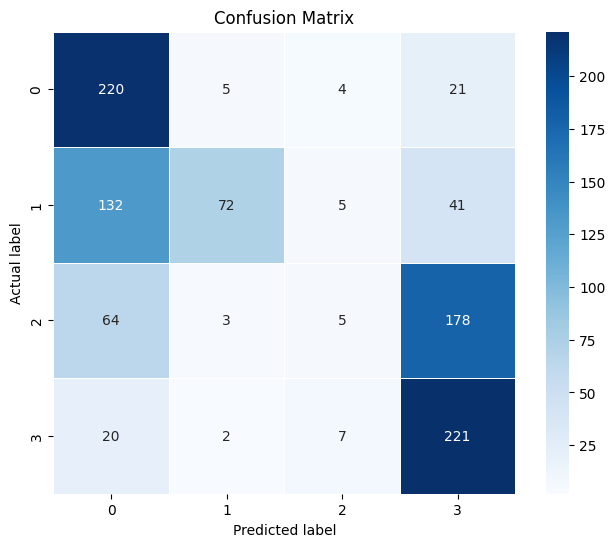

In [52]:
import matplotlib.pyplot as plt

# Define the confusion matrix
confusion_matrix = [[220,   5,   4,  21],
                    [132,  72,   5,  41],
                    [ 64,   3,   5, 178],
                    [20,   2,   7, 221]]

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", linewidths=.5, square=True, cmap="Blues")

# Set labels and title
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix")

# Show the plot
plt.show()

In [71]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Assuming you have predictions (y_pred) and true labels (test_y)
n_classes = len(np.unique(test_y))  # Get the number of unique classes

# Empty dictionaries to store ROC curves and AUCs
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Convert true labels to binary format (1 for the current class, 0 for others)
    y_true_binary = np.where(test_y == i, 1, 0)

    # Calculate ROC curve and AUC for the current class
    fpr[i], tpr[i], _ = roc_curve(y_true_binary, Y_pred_ensemble)


    roc_auc[i] = auc(fpr[i], tpr[i])


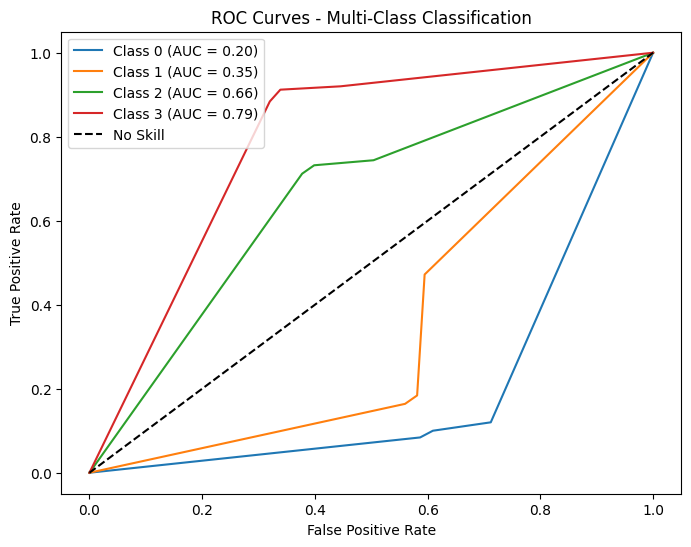

In [72]:
# Define a figure size for better readability (optional)
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    # Set labels for each class (optional)
    plt.plot(fpr[i], tpr[i], label='Class %d (AUC = %0.2f)' % (i, roc_auc[i]))

# Plot the diagonal line (ideal classifier) for reference (optional)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='No Skill')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-Class Classification')
plt.legend()


In [73]:
# Repeat but with a grid search on each level of the classifier

In [84]:
param_grid = {
  'n_neighbors': np.arange(2, 50, 1),  # Range of neighbors for KNN
  'leaf_size': np.arange(0, 200, 10)
}


In [85]:
%%time

# Define the ensemble classifier
knn_clf = KNeighborsClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(knn_clf, param_grid, scoring='accuracy', cv=2)  # Adjust cv for validation

# Fit the grid search to the training data
grid_search.fit(train_x[:1000], train_y[:1000])




CPU times: user 3min, sys: 668 ms, total: 3min 1s
Wall time: 2min 14s


GridSearchCV(cv=2, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190]),
                         'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])},
             scoring='accuracy')

In [86]:
# Get the best parameters from the grid search
best_params = grid_search.best_params_

print(best_params)

{'leaf_size': 10, 'n_neighbors': 9}


In [103]:
param_grid = {
  'n_estimators': np.arange(500, 5000, 500),  # Range of neighbors for KNN
  'max_depth': np.arange(1, 21, 5)
}


In [104]:
%%time

# Define the ensemble classifier
rf_clf = RandomForestClassifier()


# Create the GridSearchCV object
grid_search = GridSearchCV(rf_clf, param_grid, scoring='accuracy', cv=2)  # Adjust cv for validation

# Fit the grid search to the training data
grid_search.fit(train_x[:500], train_y[:500])

CPU times: user 11min 26s, sys: 1.39 s, total: 11min 28s
Wall time: 11min 33s


GridSearchCV(cv=2, estimator=RandomForestClassifier(),
             param_grid={'max_depth': array([ 1,  6, 11, 16]),
                         'n_estimators': array([ 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500])},
             scoring='accuracy')

In [105]:
# Get the best parameters from the grid search
best_params = grid_search.best_params_

print(best_params)

{'max_depth': 11, 'n_estimators': 1000}


In [107]:
# Initialize the KNN and Random Forest classifiers
knn = KNeighborsClassifier(n_neighbors= 9, leaf_size = 10)
rf = RandomForestClassifier(n_estimators = 1000, max_depth = 11)

# Ensemble classifier
ensemble_clf = VotingClassifier(estimators=[('knn', knn), ('rf', rf)], voting='hard', verbose = 0)


# Fit on the training data
ensemble_clf.fit(train_x[:40000], train_y[:40000])

# Predict
Y_pred_ensemble = ensemble_clf.predict(test_x)

# Accuracy
acc_ensemble = accuracy_score(test_y, Y_pred_ensemble)

# Precision (average across all classes)
precision = precision_score(test_y, Y_pred_ensemble, average='weighted')

# Recall (average across all classes)
recall = recall_score(test_y, Y_pred_ensemble, average='weighted')

# Confusion Matrix (was recieving a 'list' object is not callable error)
#confusion_matrix = confusion_matrix(test_y, Y_pred_ensemble)

# Print the accuracy
print("Ensemble accuracy:", acc_ensemble)

Ensemble accuracy: 0.484


In [108]:

print("Recall:", recall)

Recall: 0.484


In [109]:
#precision
print("Precision:", precision)

Precision: 0.5552495534022628


In [ ]:
import matplotlib.pyplot as plt

# Define the confusion matrix
confusion_matrix = [[220,   5,   4,  21],
                    [132,  72,   5,  41],
                    [ 64,   3,   5, 178],
                    [20,   2,   7, 221]]

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", linewidths=.5, square=True, cmap="Blues")

# Set labels and title
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix")

# Show the plot
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Assuming you have predictions (y_pred) and true labels (test_y)
n_classes = len(np.unique(test_y))  # Get the number of unique classes

# Empty dictionaries to store ROC curves and AUCs
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Convert true labels to binary format (1 for the current class, 0 for others)
    y_true_binary = np.where(test_y == i, 1, 0)

    # Calculate ROC curve and AUC for the current class
    fpr[i], tpr[i], _ = roc_curve(y_true_binary, Y_pred_ensemble)


    roc_auc[i] = auc(fpr[i], tpr[i])


In [ ]:
# Define a figure size for better readability (optional)
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    # Set labels for each class (optional)
    plt.plot(fpr[i], tpr[i], label='Class %d (AUC = %0.2f)' % (i, roc_auc[i]))

# Plot the diagonal line (ideal classifier) for reference (optional)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='No Skill')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-Class Classification')
plt.legend()


Appendix 2:

In [ ]:
#Radi's code

In [ ]:
import pandas as pd
import numpy as np

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import sys
import os                       # OS is for interfacing your own operative system
import time                     # Time is for estimating the computational time of every operation
import matplotlib               # MatPlotLib is for making plots & figures
import matplotlib.pyplot as plt # PyPlot is a subset of the library for making MATLAB-style plots
import tensorflow as tf         # Tensorflow from Google
from tensorflow import keras    # Keras library from Tensorflow
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, InputLayer, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from tensorflow.keras.layers import InputLayer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

**Appendix 2a** - Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

list_files = '/content/drive/My Drive/BME4810FP/Project_Packet/octmnist.npz'

data = np.load(list_files)

for name in data:
  print(name)
  print(data[name])

X_train = data['train_images']
y_train = data['train_labels']
X_test = data['test_images']
y_test = data['test_labels']
X_val = data['val_images']
y_val = data['val_labels']

Mounted at /content/drive
train_images
[[[ 23  24  25 ...  25  25  25]
  [ 23  24  25 ...  25  25  25]
  [ 22  24  25 ...  24  24  24]
  ...
  [ 13  13  13 ...  29  31  32]
  [ 12  12  12 ...  19  21  21]
  [ 10  10  10 ...  12  14  14]]

 [[ 34  33  31 ... 102 111 120]
  [ 32  31  30 ...  28  30  31]
  [ 28  27  26 ...  36  34  32]
  ...
  [ 11  11  12 ...  15  14  14]
  [ 27  24  21 ...  14  14  14]
  [197 190 180 ...  14  14  13]]

 [[172 168 161 ...  30  27  27]
  [ 31  31  31 ...  30  27  26]
  [ 29  30  31 ...  26  23  22]
  ...
  [ 17  17  16 ...  13  13  13]
  [ 16  15  14 ...  12  12  12]
  [ 15  14  13 ...  11  11  11]]

 ...

 [[ 35  41  52 ... 255 255 255]
  [ 42  39  35 ... 230 237 245]
  [ 28  27  26 ...  66  74  81]
  ...
  [ 15  15  15 ...  17  17  17]
  [ 14  14  14 ...  15  15  15]
  [ 13  13  13 ...  14  14  14]]

 [[ 28  27  28 ... 142 159 170]
  [ 28  28  28 ...  24  33  37]
  [ 27  27  27 ...  33  34  32]
  ...
  [ 11   9   8 ...  12  12  12]
  [104  96  83 ...  1

**Appendix 2b** - CNN1, Version 1

In [ ]:
CNN1 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')])

CNN1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

running  = CNN1.fit(X_train, y_train, epochs=10,
                    validation_data=(X_val, y_val))

val_loss, val_accuracy = CNN1.evaluate(X_val, y_val, verbose=0)


y_pred_prob = CNN1.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)



precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

conf_matrix = confusion_matrix(y_val, y_pred)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))
print("Confusion Matrix:\n", conf_matrix)




Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


3047/3047 [==============================] - 108s 35ms/step - loss: 0.6048 - accuracy: 0.7977 - val_loss: 0.4483 - val_accuracy: 0.8512
Epoch 2/10
3047/3047 [==============================] - 109s 36ms/step - loss: 0.4542 - accuracy: 0.8471 - val_loss: 0.4205 - val_accuracy: 0.8524
Epoch 3/10
3047/3047 [==============================] - 104s 34ms/step - loss: 0.4087 - accuracy: 0.8601 - val_loss: 0.4150 - val_accuracy: 0.8555
Epoch 4/10
3047/3047 [==============================] - 106s 35ms/step - loss: 0.3796 - accuracy: 0.8713 - val_loss: 0.3755 - val_accuracy: 0.8741
Epoch 5/10
3047/3047 [==============================] - 106s 35ms/step - loss: 0.3603 - accuracy: 0.8773 - val_loss: 0.3537 - val_accuracy: 0.8753
Epoch 6/10
3047/3047 [==============================] - 105s 35ms/step - loss: 0.3458 - accuracy: 0.8813 - val_loss: 0.3369 - val_accuracy: 0.8859
Epoch 7/10
3047/3047 [==============================] - 107s 35ms/step - loss: 0.3328 - accuracy: 0.8859 - val_loss: 0.3379 - val

**Appendix 2c** - CNN2, Version 2

In [ ]:
CNN1 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu'),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])


CNN1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

running  = CNN1.fit(X_train, y_train, epochs=10,
                    validation_data=(X_val, y_val))

val_loss, val_accuracy = CNN1.evaluate(X_val, y_val, verbose=0)


y_pred_prob = CNN1.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)



precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

conf_matrix = confusion_matrix(y_val, y_pred)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))
print("Confusion Matrix:\n", conf_matrix)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


3047/3047 [==============================] - 158s 51ms/step - loss: 0.6047 - accuracy: 0.8023 - val_loss: 0.8794 - val_accuracy: 0.6773
Epoch 2/10
3047/3047 [==============================] - 154s 51ms/step - loss: 0.4452 - accuracy: 0.8539 - val_loss: 0.3878 - val_accuracy: 0.8650
Epoch 3/10
3047/3047 [==============================] - 154s 51ms/step - loss: 0.3887 - accuracy: 0.8706 - val_loss: 0.4342 - val_accuracy: 0.8590
Epoch 4/10
3047/3047 [==============================] - 154s 51ms/step - loss: 0.3543 - accuracy: 0.8830 - val_loss: 0.4587 - val_accuracy: 0.8553
Epoch 5/10
3047/3047 [==============================] - 154s 50ms/step - loss: 0.3303 - accuracy: 0.8909 - val_loss: 0.3358 - val_accuracy: 0.8840
Epoch 6/10
3047/3047 [==============================] - 177s 58ms/step - loss: 0.3075 - accuracy: 0.8978 - val_loss: 0.3272 - val_accuracy: 0.8919
Epoch 7/10
3047/3047 [==============================] - 155s 51ms/step - loss: 0.2935 - accuracy: 0.9034 - val_loss: 0.3165 - val

**Appendix 2d** - CNN2, Version 1

In [ ]:
CNN2 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])


CNN2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

running  = CNN2.fit(X_train, y_train, epochs=10,
                    validation_data=(X_val, y_val))

val_loss, val_accuracy = CNN2.evaluate(X_val, y_val, verbose=0)


y_pred_prob = CNN2.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)



precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

conf_matrix = confusion_matrix(y_val, y_pred)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))
print("Confusion Matrix:\n", conf_matrix)

Epoch 1/10
3047/3047 [==============================] - 620s 202ms/step - loss: 0.5576 - accuracy: 0.8175 - val_loss: 0.4220 - val_accuracy: 0.8578
Epoch 2/10
3047/3047 [==============================] - 521s 171ms/step - loss: 0.3805 - accuracy: 0.8743 - val_loss: 0.3403 - val_accuracy: 0.8847
Epoch 3/10
3047/3047 [==============================] - 510s 167ms/step - loss: 0.3232 - accuracy: 0.8913 - val_loss: 0.5193 - val_accuracy: 0.8365
Epoch 4/10
3047/3047 [==============================] - 520s 171ms/step - loss: 0.2891 - accuracy: 0.9014 - val_loss: 0.3782 - val_accuracy: 0.8834
Epoch 5/10
3047/3047 [==============================] - 515s 169ms/step - loss: 0.2690 - accuracy: 0.9085 - val_loss: 0.2806 - val_accuracy: 0.9056
Epoch 6/10
3047/3047 [==============================] - 517s 170ms/step - loss: 0.2451 - accuracy: 0.9171 - val_loss: 0.2916 - val_accuracy: 0.9090
Epoch 7/10
3047/3047 [==============================] - 515s 169ms/step - loss: 0.2258 - accuracy: 0.9244 - val_

**Appendix 2e** - CNN2, Version 2

In [ ]:
CNN2 = Sequential([
    Conv2D(32, kernel_size=(5, 5), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

CNN2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

running  = CNN2.fit(X_train, y_train, epochs=10,
                    validation_data=(X_val, y_val))

val_loss, val_accuracy = CNN2.evaluate(X_val, y_val, verbose=0)


y_pred_prob = CNN2.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)



precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

conf_matrix = confusion_matrix(y_val, y_pred)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))
print("Confusion Matrix:\n", conf_matrix)

Epoch 1/10
3047/3047 [==============================] - 626s 205ms/step - loss: 0.5027 - accuracy: 0.8332 - val_loss: 0.3974 - val_accuracy: 0.8654
Epoch 2/10
3047/3047 [==============================] - 732s 240ms/step - loss: 0.3440 - accuracy: 0.8851 - val_loss: 0.3086 - val_accuracy: 0.8881
Epoch 3/10
3047/3047 [==============================] - 659s 216ms/step - loss: 0.2996 - accuracy: 0.8990 - val_loss: 0.5203 - val_accuracy: 0.8045
Epoch 4/10
3047/3047 [==============================] - 621s 204ms/step - loss: 0.2732 - accuracy: 0.9082 - val_loss: 0.5120 - val_accuracy: 0.8205
Epoch 5/10
3047/3047 [==============================] - 625s 205ms/step - loss: 0.2538 - accuracy: 0.9150 - val_loss: 0.2601 - val_accuracy: 0.9102
Epoch 6/10
3047/3047 [==============================] - 620s 203ms/step - loss: 0.2326 - accuracy: 0.9217 - val_loss: 0.2888 - val_accuracy: 0.8990
Epoch 7/10
3047/3047 [==============================] - 629s 206ms/step - loss: 0.2202 - accuracy: 0.9271 - val_

**Appendix 2f** - MLP, Version 1

In [ ]:
scaler = StandardScaler()
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)

pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

MLP = Sequential([
    InputLayer(input_shape=(50,)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])
MLP.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

running  = MLP.fit(X_train_pca, y_train, epochs=10,
                    validation_data=(X_val_pca, y_val))

val_loss, val_accuracy = MLP.evaluate(X_val_pca, y_val, verbose=0)


y_pred_prob = MLP.predict(X_val_pca)
y_pred = np.argmax(y_pred_prob, axis=1)



precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

conf_matrix = confusion_matrix(y_val, y_pred)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))
print("Confusion Matrix:\n", conf_matrix)


Epoch 1/10
3047/3047 [==============================] - 9s 3ms/step - loss: 1.0954 - accuracy: 0.6093 - val_loss: 0.7891 - val_accuracy: 0.7062
Epoch 2/10
3047/3047 [==============================] - 6s 2ms/step - loss: 0.8174 - accuracy: 0.7010 - val_loss: 0.6967 - val_accuracy: 0.7484
Epoch 3/10
3047/3047 [==============================] - 8s 2ms/step - loss: 0.7625 - accuracy: 0.7247 - val_loss: 0.6602 - val_accuracy: 0.7643
Epoch 4/10
3047/3047 [==============================] - 6s 2ms/step - loss: 0.7399 - accuracy: 0.7334 - val_loss: 0.6450 - val_accuracy: 0.7677
Epoch 5/10
3047/3047 [==============================] - 8s 3ms/step - loss: 0.7271 - accuracy: 0.7391 - val_loss: 0.6382 - val_accuracy: 0.7666
Epoch 6/10
3047/3047 [==============================] - 7s 2ms/step - loss: 0.7162 - accuracy: 0.7438 - val_loss: 0.6264 - val_accuracy: 0.7705
Epoch 7/10
3047/3047 [==============================] - 9s 3ms/step - loss: 0.7087 - accuracy: 0.7466 - val_loss: 0.6217 - val_accuracy:

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Appendix 2g** - MLP, Version 2

In [ ]:
MLP = Sequential([
    InputLayer(input_shape=(50,)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),

    Dense(128, activation='relu'),
    Dropout(0.4),
    BatchNormalization(),

    Dense(64, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),

    Dense(32, activation='relu'),
    Dropout(0.2),
    BatchNormalization(),

    Dense(4, activation='softmax')
])

MLP.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

running  = MLP.fit(X_train_pca, y_train, epochs=10,
                    validation_data=(X_val_pca, y_val))

val_loss, val_accuracy = MLP.evaluate(X_val_pca, y_val, verbose=0)


y_pred_prob = MLP.predict(X_val_pca)
y_pred = np.argmax(y_pred_prob, axis=1)



precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

conf_matrix = confusion_matrix(y_val, y_pred)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))
print("Confusion Matrix:\n", conf_matrix)


Epoch 1/10
3047/3047 [==============================] - 22s 6ms/step - loss: 1.0893 - accuracy: 0.5698 - val_loss: 0.8820 - val_accuracy: 0.6817
Epoch 2/10
3047/3047 [==============================] - 15s 5ms/step - loss: 0.9070 - accuracy: 0.6672 - val_loss: 0.7562 - val_accuracy: 0.7201
Epoch 3/10
3047/3047 [==============================] - 15s 5ms/step - loss: 0.8421 - accuracy: 0.6895 - val_loss: 0.7104 - val_accuracy: 0.7501
Epoch 4/10
3047/3047 [==============================] - 15s 5ms/step - loss: 0.8085 - accuracy: 0.7073 - val_loss: 0.6830 - val_accuracy: 0.7647
Epoch 5/10
3047/3047 [==============================] - 15s 5ms/step - loss: 0.7881 - accuracy: 0.7147 - val_loss: 0.6577 - val_accuracy: 0.7700
Epoch 6/10
3047/3047 [==============================] - 16s 5ms/step - loss: 0.7745 - accuracy: 0.7210 - val_loss: 0.6563 - val_accuracy: 0.7777
Epoch 7/10
3047/3047 [==============================] - 28s 9ms/step - loss: 0.7644 - accuracy: 0.7258 - val_loss: 0.6364 - val_ac

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Appendix 2h** - Gridsearch on CNN2, Version 1

In [ ]:
X_train_half, X_unused, y_train_half, y_unused = train_test_split(X_train, y_train, test_size=0.5, random_state=30)


neurons = [16, 32, 64]
activations = ['relu', 'tanh']
optimizers = ['adam', 'rmsprop']


NetworkRun = 0
best_accuracy = 0

#Gridsearch
for opt in optimizers:
    for act in activations:
        for neu in neurons:

            NetworkRun += 1

            CNN2 = Sequential([
                  Conv2D(neu*2, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
                  BatchNormalization(),
                  MaxPooling2D(pool_size=(2, 2)),
                  Conv2D(neu*4, (3, 3), activation='relu', padding='same'),
                  BatchNormalization(),
                  MaxPooling2D(pool_size=(2, 2)),
                  Conv2D(neu*8, (3, 3), activation='relu', padding='same'),
                  BatchNormalization(),
                  Conv2D(256, (3, 3), activation='relu', padding='same'),
                  MaxPooling2D(pool_size=(2, 2)),
                  Flatten(),
                  Dense(128, activation='relu'),
                  Dropout(0.5),
                  Dense(4, activation='softmax')
                                                  ])


            CNN2.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

            running  = CNN2.fit(X_train_half, y_train_half, epochs=10,
                    validation_data=(X_val, y_val))

            val_loss, val_accuracy = CNN2.evaluate(X_val, y_val, verbose=0)


            print(f"Validation {NetworkRun}: Optimizer={opt}, Activation={act}, Neuron={neu}, Accuracy={val_accuracy}")

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_network = {'optimizer': opt, 'activation': act, 'neuron scale': neu}


print("Best Network:", best_network, best_accuracy)


Epoch 1/10
1524/1524 [==============================] - 246s 158ms/step - loss: 0.6962 - accuracy: 0.7642 - val_loss: 0.8488 - val_accuracy: 0.7112
Epoch 2/10
1524/1524 [==============================] - 228s 149ms/step - loss: 0.4933 - accuracy: 0.8403 - val_loss: 1.0764 - val_accuracy: 0.6801
Epoch 3/10
1524/1524 [==============================] - 232s 152ms/step - loss: 0.4195 - accuracy: 0.8622 - val_loss: 0.4626 - val_accuracy: 0.8573
Epoch 4/10
1524/1524 [==============================] - 234s 153ms/step - loss: 0.3722 - accuracy: 0.8735 - val_loss: 0.4355 - val_accuracy: 0.8573
Epoch 5/10
1524/1524 [==============================] - 225s 147ms/step - loss: 0.3454 - accuracy: 0.8811 - val_loss: 0.3292 - val_accuracy: 0.8893
Epoch 6/10
1524/1524 [==============================] - 226s 148ms/step - loss: 0.3037 - accuracy: 0.8967 - val_loss: 0.3359 - val_accuracy: 0.8853
Epoch 7/10
1524/1524 [==============================] - 224s 147ms/step - loss: 0.2859 - accuracy: 0.9024 - val_

I was not supplied the rest of the code yet.